# Q2. Can a small classifier on frozen Evo2 representations outperform zero-shot Evo2 scoring for missense variants in previously unseen genes?

Add **Evo2 7B base zero-shot** as a frozen-model baseline, using the full **6 July 2026** ClinVar validation partition shared by Q0 and Q1. [Dependencies](../requirements.txt) · [7B implementation](src/q2_7b.py).

The completed [1B classifier comparison](results/archive/before_shared_july_snapshot/notebooks/Q2-evo2-classifier.ipynb) uses the archived September pilot. Its predictions and labels remain separate from this July experiment.

## Frozen full inputs

Use Q1's full [training VCF](../data/clinvar-train.vcf) and [validation VCF](../data/clinvar-test.vcf), with the same missense filters and gene/locus/source-ID/context grouping. Training variants supply only inference-check examples. **No classifier, scaling, threshold or hyperparameter is fitted.**

The workflow verifies the source snapshot, complete split manifests, reference/alternate DNA and leakage checks before scoring. Only DNA enters the predictor.

In [1]:
from src import q2_7b
full_validation_sequences = q2_7b.prepare()

Verify ClinVar 2026-07-06, shared with Q0, and inherited group assignments.


5,000 sampled variants retained; 6 leakage check groups passed.


64,815 full-dataset variants; 0 sequence exclusions; 8 audit groups passed.


Evo2 7B base zero-shot (Vortex, FP8): 17,927 full validation variants; no fitting or selection.


## Evo2 7B zero-shot

Use [Evo2 7B base](https://huggingface.co/arcinstitute/evo2_7b_base/tree/074097e9dc788e8bfe045d6495b9f6153a7c6bfc) with **Vortex/FP8**, 1,024-base contexts and seed 42. The score is the negative alternate-minus-reference mean next-token log likelihood, averaged over both strands—the same definition as the earlier 1B zero-shot baseline.

Verify the 13 GB checkpoint, fixed FP8 scales, A/B/A repeatability and strand invariance. Batch size **1** preserves independent scoring; larger training-probe batches changed likelihoods. Use the shared Q2 GPU environment; full inference takes about **two hours on an L40S**, with resumable 100-variant batches.

[Progress log](results/q2/7b/inference.log) · [7B protocol](results/q2/7b/protocol.json)

In [2]:
q2_7b.run()

7B full-validation inference; resumable progress: results/q2/7b/inference.log


Completed and verified all 7B full-validation scores.


## Full validation

Report AUROC and average precision on **every current full validation variant**, with 1,000 component-bootstrap resamples (seed 42). The README row uses this exact cohort. No September scores or labels are reused.

[Predictions](results/q2/7b/validation_predictions.csv) · [Inference checks](results/q2/7b/preflight.json). Homology, shared patients, pretraining overlap and annotation circularity remain unresolved. The test-named VCF is development validation.

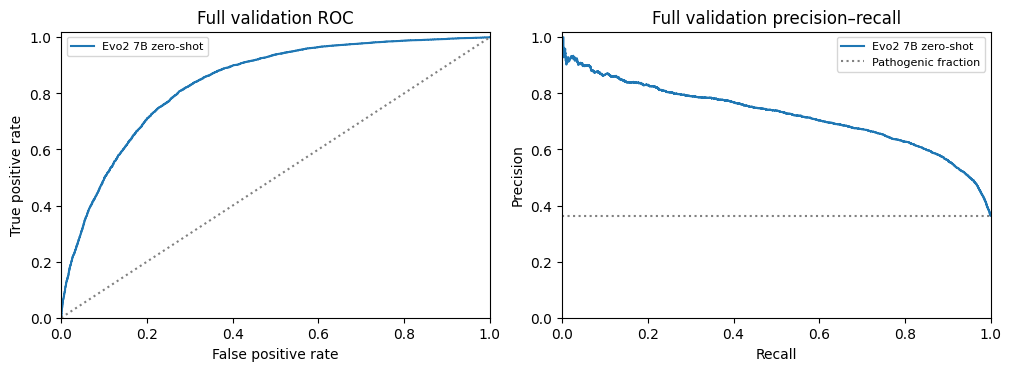

**7B · 2026-07-06 · 17,927 validation variants**: auroc **0.837** [0.824, 0.849]; average precision **0.724** [0.686, 0.755].

In [3]:
result_7b = q2_7b.evaluate()
q2_7b.show_results(result_7b)

## Conclusion

In [4]:
q2_7b.show_conclusion(result_7b)

**Evo2 7B zero-shot** reaches AUROC **0.837** and average precision **0.724** on **17,927** full ClinVar 2026-07-06 validation variants. This zero-shot extension does not establish an advantage for a fitted classifier; the earlier 1B classifier comparison belongs to the archived September pilot. These are development results with unresolved pretraining and homology overlap.